# EuroSAT Data Exploration
Loading the dataset, viewing sample images, and checking the class distribution.

In [16]:
import sys
sys.path.append("..") 

import random
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import EuroSAT

from src.data import CLASS_NAMES, DATA_ROOT

ASSETS = DATA_ROOT.parent / "assets"
ASSETS.mkdir(exist_ok=True)

A 3x3 grid of random samples with their labels, loaded from the raw dataset
(no normalisation) so the colours display truthfully. This is a quick visual
check that the loader returns sensible images matched to the right class names.

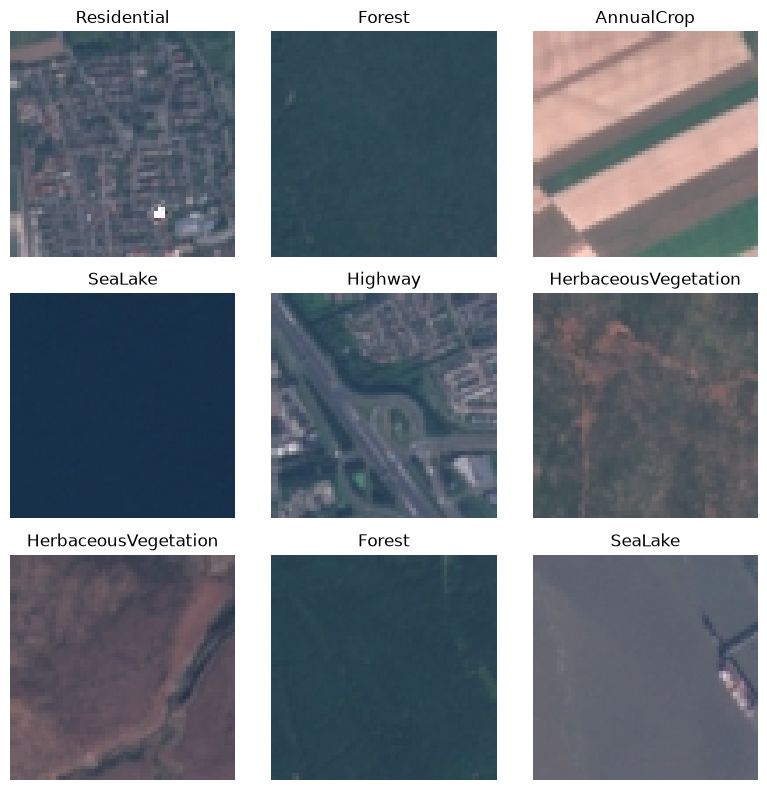

In [17]:
random.seed(42)   

raw = EuroSAT(root=str(DATA_ROOT), download=True)

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for ax in axes.flat:
    idx = random.randrange(len(raw))
    img, label = raw[idx]                 
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[label])      
    ax.axis("off")

plt.tight_layout()
plt.savefig(ASSETS / "samples.png", dpi=150, bbox_inches="tight")
plt.show()

The classes are mildly imbalanced, ranging from ~2,000 to ~3,000 images
(about a 1.5x ratio). This is gentle enough that I don't need resampling or
class weighting for the baseline, but it does mean raw accuracy can be slightly
misleading, so in evaluation I'll rely on per-class precision/recall/F1 rather
than accuracy alone.

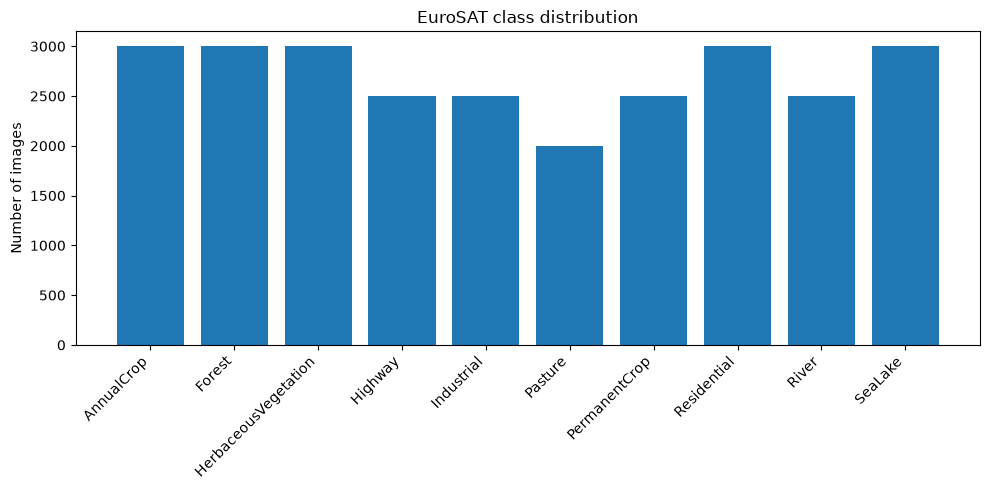

AnnualCrop             3000
Forest                 3000
HerbaceousVegetation   3000
Highway                2500
Industrial             2500
Pasture                2000
PermanentCrop          2500
Residential            3000
River                  2500
SeaLake                3000
min: 2000  max: 3000  ratio: 1.50


In [18]:
counts = np.bincount(raw.targets)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(CLASS_NAMES, counts)
ax.set_ylabel("Number of images")
ax.set_title("EuroSAT class distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(ASSETS / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

for name, c in zip(CLASS_NAMES, counts):
    print(f"{name:22s} {c}")
print("min:", counts.min(), " max:", counts.max(),
      " ratio: %.2f" % (counts.max() / counts.min()))